In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import mod as m 

In [11]:
date = '04-17-26'
path = f'Data/HighPressureTesting-{date}/'
ps = [363, 405, 455, 505, 555, 605, 655, 705, 755, 855, 905, 955, 1005]

## Check io

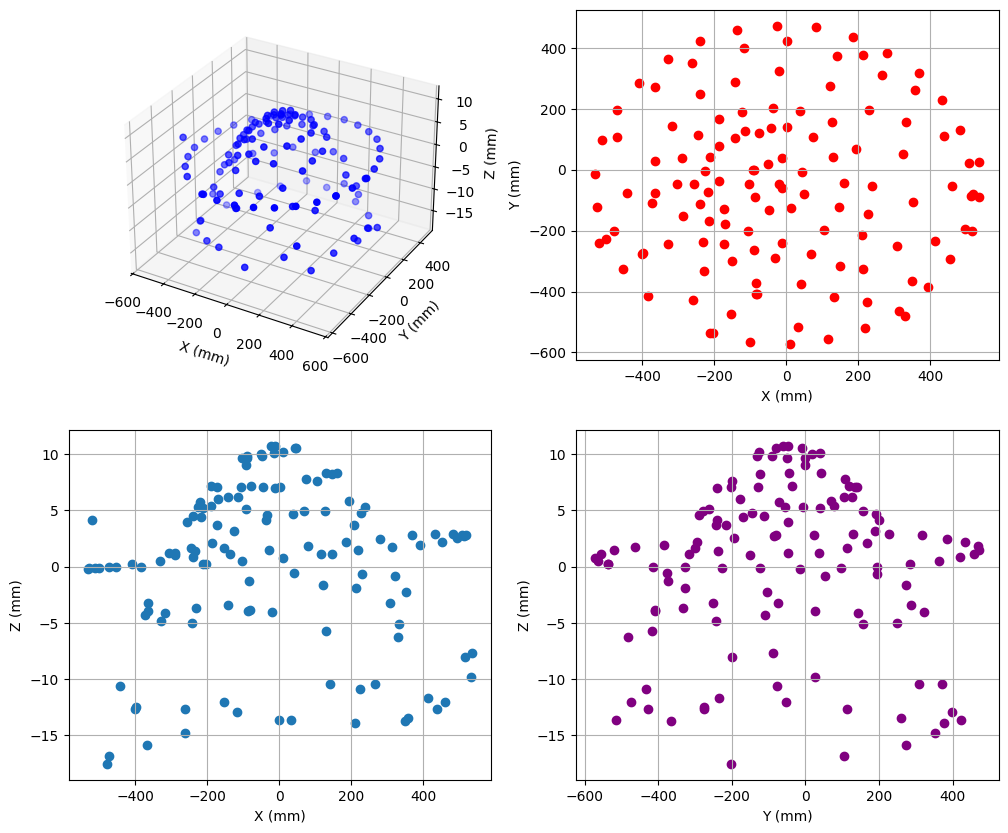

In [19]:
arr = np.loadtxt(path+f"WithRing-{ps[1]}Pa.txt")
m.vis(arr[:,0], arr[:,1], arr[:,2], date)

In [20]:
Xg, Yg, Zg = m.surfacefit(arr[:,0], arr[:,1], arr[:,2], gridsize = 400)

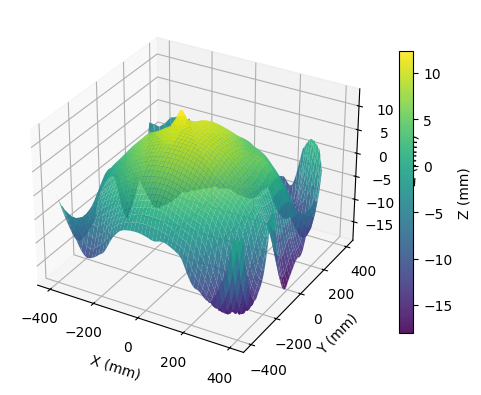

In [21]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.9)
# ax.scatter(Xr, Yr, Zr, color='red', s=40)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')

fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()

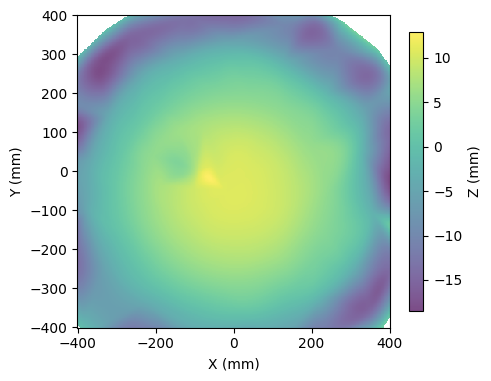

In [22]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

surf = ax.pcolormesh(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.7)
# ax.scatter(Xg, Yg, Zg, color='red')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')

ax.set_aspect("equal")
fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()

## Compress data 

-9.991369891932028 -50.151289235788745
522.2649818899259


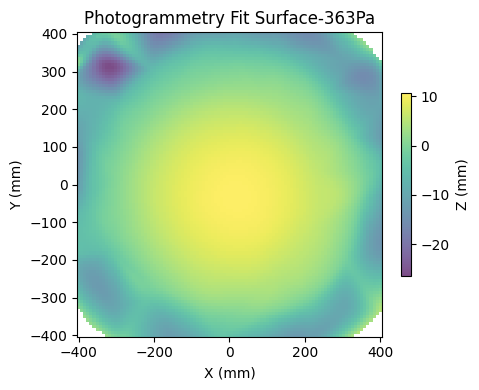

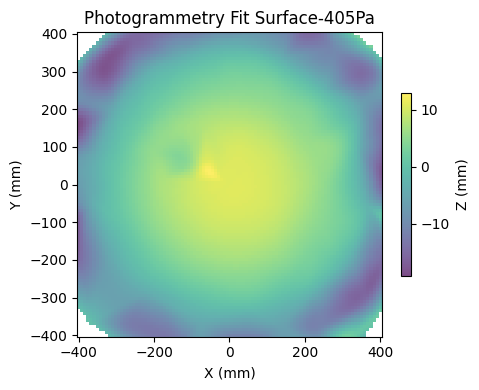

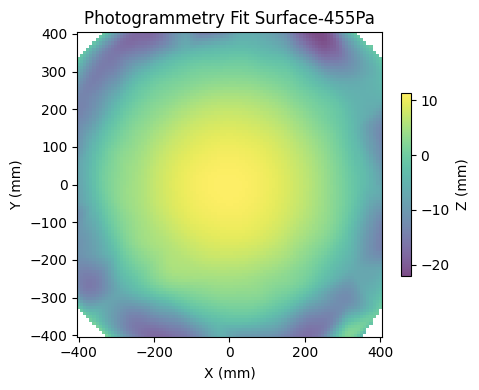

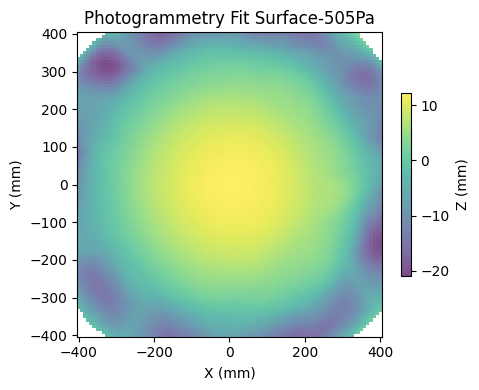

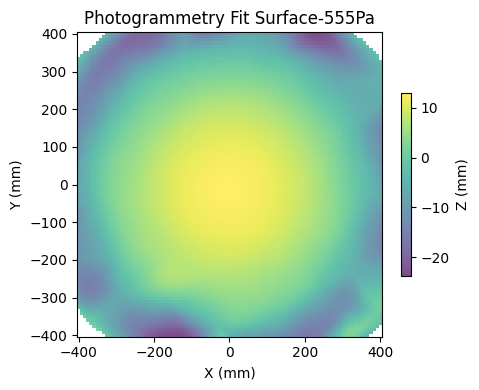

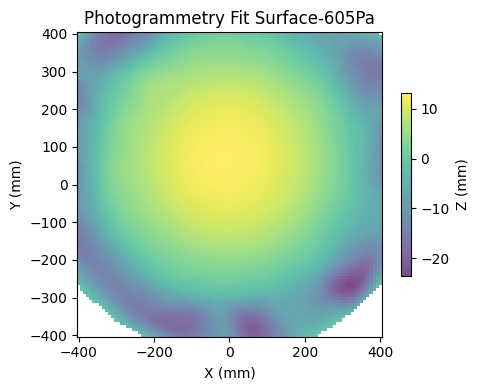

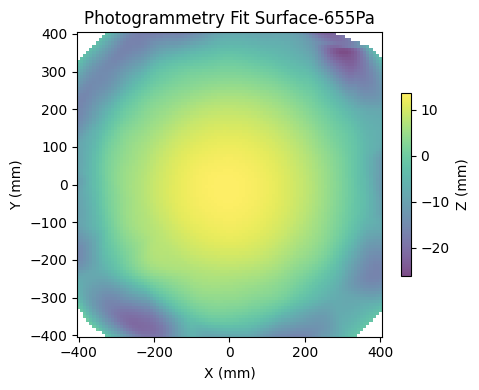

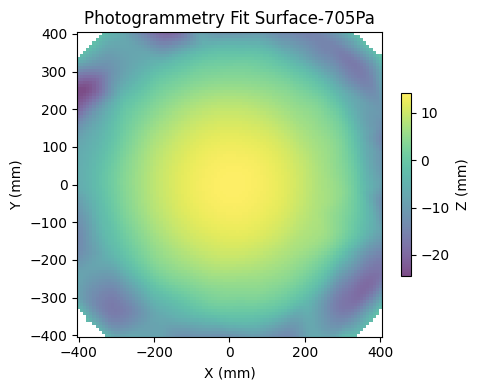

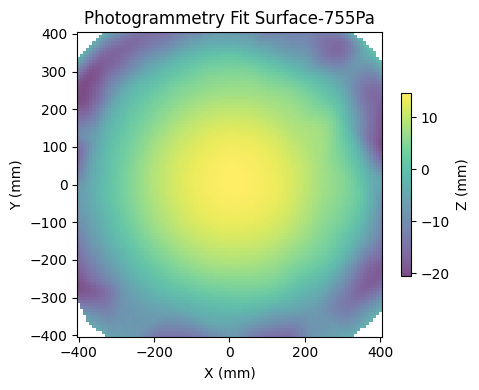

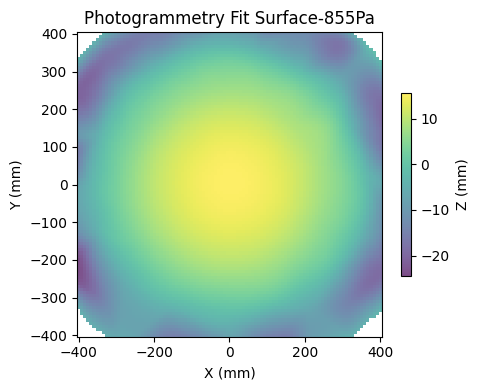

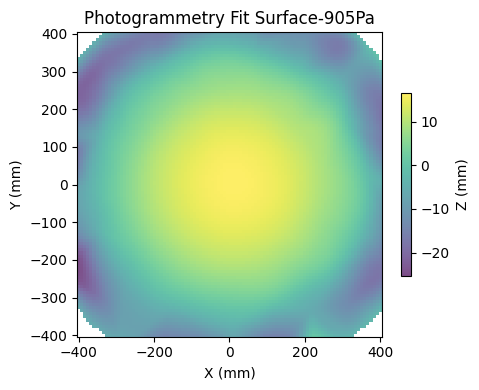

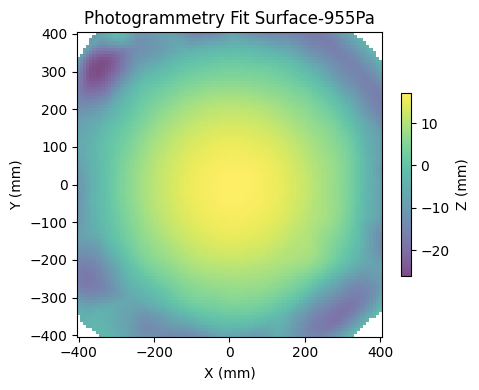

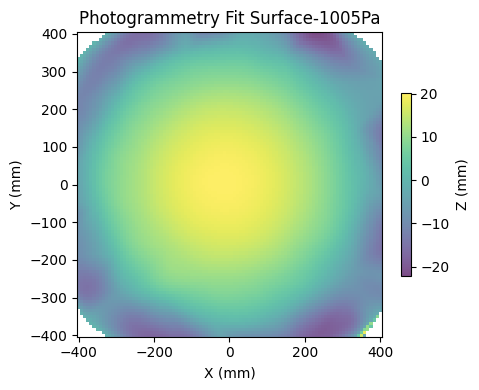

In [7]:
fits = [] 
for i, p in enumerate(ps): 
    
    arr = np.loadtxt(path+f"WithRing-{p}Pa.txt")
    if i==0: 
        # get center of the ring

        x0, y0, r = m.circleRadius(
            [arr[1,0], arr[1,1]], 
            [arr[28,0], arr[28,1]], 
            [arr[103,0], arr[103,1]]
        )
        print(x0, y0)
        print(r)
    
    # shift center 
    arr = arr.copy() 
    arr[:,0] -= x0 
    arr[:,1] -= y0
    
    Xg, Yg, Zg = m.surfacefit(arr[:,0], arr[:,1], arr[:,2], gridsize=100)
    fits.append({
        "p": p,
        "Xg": Xg,
        "Yg": Yg,
        "Zg": Zg
    })
    
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot()

    surf = ax.pcolormesh(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.7)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title(f"Photogrammetry Fit Surface-{p}Pa")
    ax.set_aspect("equal")
    fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
    plt.tight_layout()
    fig.savefig(f"figs/PhotogrammetryFit-{date}-{p}Pa.jpg")

In [8]:
def extract_cuts(Xg, Yg, Zg):
    ny, nx = Zg.shape
    ix = nx // 2   # middle column
    iy = ny // 2   # middle row

    x_xz = Xg[iy, :]
    z_xz = Zg[iy, :]

    y_yz = Yg[:, ix]
    z_yz = Zg[:, ix]

    return (x_xz, z_xz), (y_yz, z_yz)


In [9]:
def min_gradient(x, y):
    '''This function find a x axis position where gradient of the curve is 0. 
    Input: 
        x, y (narray) 
    Output:
        x0 x value where gradient is 0. 
    '''
    
    dydx = np.gradient(y, x)
    i0 = np.nanargmin(np.abs(dydx))
    x0 = x[i0]
    return x0

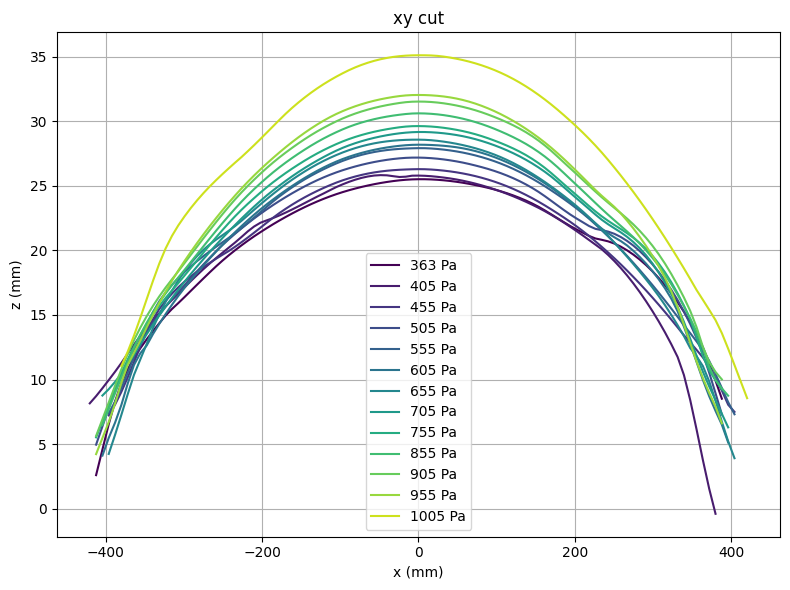

In [10]:
num_lines = len(ps)
cmap = plt.get_cmap('viridis')

plt.subplots(figsize=(8,6))

for i, fit in enumerate(fits):
    p = fit["p"]
    Xg, Yg, Zg = fit["Xg"], fit["Yg"], fit["Zg"]

    #get cut
    (x_xz, z_xz), _ = extract_cuts(Xg, Yg, Zg)
    # shift coord
    x0 = min_gradient(x_xz, z_xz)
    x_norm = x_xz - x0

# plot
    plt.plot(x_norm, 15+z_xz, label=f"{p} Pa", color=cmap(i / num_lines))

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title("xy cut")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig("figs/xz-04-17-26.jpg")


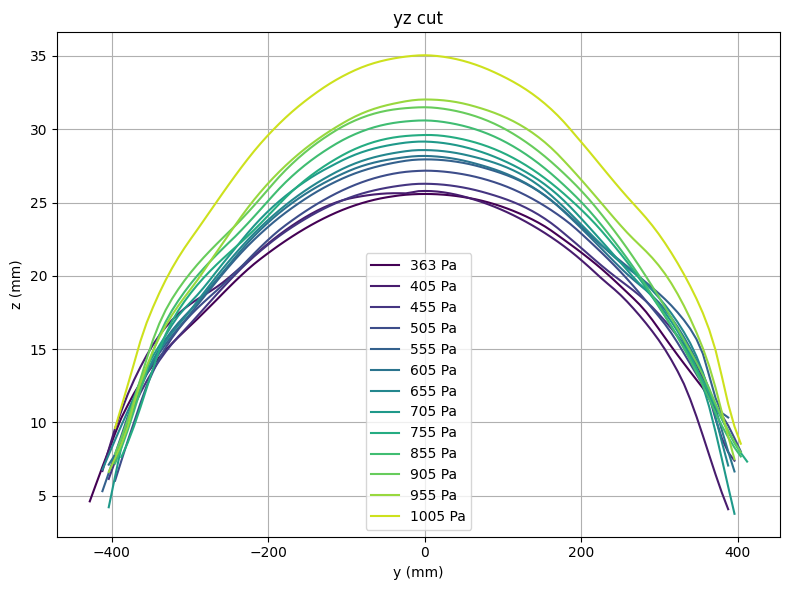

In [11]:
num_lines = len(ps)
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(8,6))

for i, fit in enumerate(fits):
    p = fit["p"]
    Xg, Yg, Zg = fit["Xg"], fit["Yg"], fit["Zg"]

    # extract cuts
    _, (y_yz, z_yz) = extract_cuts(Xg, Yg, Zg)
    
    # shift coord
    y0 = min_gradient(y_yz, z_yz)
    y_norm = y_yz - y0


#plot
    ax.plot(-y_norm, 15+z_yz, label=f"{p} Pa", color=cmap(i / num_lines))

# ax.set_facecolor("lightgray")
ax.set_xlabel("y (mm)")
ax.set_ylabel("z (mm)")
ax.set_title("yz cut")
ax.legend()
ax.grid(True)
fig.tight_layout()
#fig.show()
fig.savefig("figs/yz-04-17-26.jpg")
